In [44]:
import numpy as np
from math import exp, sqrt, log, erfc
from scipy.stats import norm
import matplotlib.pyplot as plt

**European Call Option via Binomial (CRR) Model**

In the binomial (Cox–Ross–Rubinstein, CRR) model, the price of the underlying asset is assumed to evolve on a discrete-time recombining tree. Over the life of the option, the time to maturity is divided into \(N\) small time steps, and in each step the price can move either up or down by fixed multiplicative factors. As the number of steps increases, the binomial price converges to the Black–Scholes price.

A European call option gives the holder the right, but not the obligation, to buy the underlying asset at maturity if the terminal price exceeds the strike price.

<br><br>

**Payoff Function**

$$
\max(S_T - K,\, 0)
$$

<br><br>

**Model Setup (CRR Binomial Parameters)**

$$
\Delta t = \frac{T}{N}
$$

$$
u = e^{\sigma \sqrt{\Delta t}}, 
\qquad
d = \frac{1}{u}
$$

$$
p = \frac{e^{r \Delta t} - d}{u - d}
$$

<br><br>
**Lattice Construction**

At node \((i,j)\):

$$
S_{i,j} = S_0 \, u^{\,i} d^{\,j - i}
$$

Terminal payoff:

$$
C_{i,N} = \max\left(S_{i,N} - K,\, 0\right)
$$

<br><br>

**Backward Induction**

$$
C_{i,j}
=
e^{-r \Delta t}
\Big(
p \, C_{i+1,\,j+1}
+
(1-p)\, C_{i,\,j+1}
\Big)
$$

Present value:

$$
C_0 = C_{0,0}
$$

<br><br>

**Notation**

| Symbol | Description |
|---|---|
| \(S_0\) | Spot price |
| \(K\) | Strike price |
| \(r\) | Risk-free interest rate |
| \(T\) | Time to maturity |
| \(σ\) | Volatility |
| \(N\) | Number of time steps |
| \(u\) | Upward movement factor |
| \(d\) | Downward movement factor |


<br><br>

**Summary**

- The CRR binomial model discretizes the option’s life into \(N\) steps  
- Terminal payoff is evaluated at maturity  
- Values are discounted backward using risk-neutral expectation  
- The binomial price converges to the Black–Scholes price as \(N\) increases  



In [63]:
def LatticeEurCall(S0, K, r, T, sigma, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    # Lattice (option values)
    lattice = np.zeros((N+1, N+1))
    spot = np.zeros((N+1, N+1))

    # Terminal node values
    for i in range(N+1):
        spot[i, N] = S0 * (u**i) * (d**(N-i))
        lattice[i, N] = max(0, spot[i, N] - K)

    # Backward induction
    for j in range(N-1, -1, -1):
        for i in range(j+1):
            lattice[i, j] = np.exp(-r * dt) * (p * lattice[i+1, j+1] + (1-p) * lattice[i, j+1])
            spot[i, j] = S0 * (u**i) * (d**(j-i))

    return lattice[0, 0], lattice, spot

**European Call Option via Black-Scholes Model**

The theoretical value of a European call option can be computed using the Black-Scholes model, which provides a closed-form analytical solution. 
The model assumes that the underlying asset price follows a log-normal distribution and that markets are arbitrage-free. 
A European call option gives the holder the right, but not the obligation, to buy the underlying asset at maturity if the price exceeds the strike price.
<br><br><br>

**Payoff Function**

The payoff of a European call at maturity is defined as: 
$$\max(S_T-K,0)$$
<br><br><br>

**Black-Scholes Closed-Form Solution**

The present value of a European call option is given by:

$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$

where

$$d_1 = \frac{\ln (S_0/K) + (r + \frac{\sigma^2}{2})T}{\sigma \sqrt{T}}$$

$$d_2 = d_1 - \sigma \sqrt{T}$$

**Notation**

| Symbol | Description |
|---|---|
| \(S_0\) | Spot price |
| \(K\) | Strike price |
| \(r\) | Risk-free interest rate |
| \(T\) | Time to maturity |
| \(σ\) | Volatility |

In [77]:
def black_scholes_call(S0, K, r, T, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    N = lambda x: 0.5 * erfc(-x / np.sqrt(2))

    return float(S0 * N(d1) - K * np.exp(-r*T) * N(d2))

**Convergence of the Binomial Model to the Black-Scholes Price**

In [62]:
S0 = 60
K = 70
r = 0.2
T = 0.5
sigma = 0.6

In [ ]:
print("Black–Scholes Price =", black_scholes_call(S0,K,r,T,sigma))
for N in (5,10,50,100):
    print(f"Binomial Price = {LatticeEurCall(S0,K,r,T,sigma,N)[0]} - N={N}") 

Black–Scholes Price = 8.773876274808437
Binomial Price = 8.529372794206257 - N=5
Binomial Price = 8.97690516143434 - N=10
Binomial Price = 8.796654369962027 - N=50
Binomial Price = 8.774691375708539 - N=100


Text(0.5, 1.0, 'Binomial Model vs Black-Scholes for Different Step Sizes')

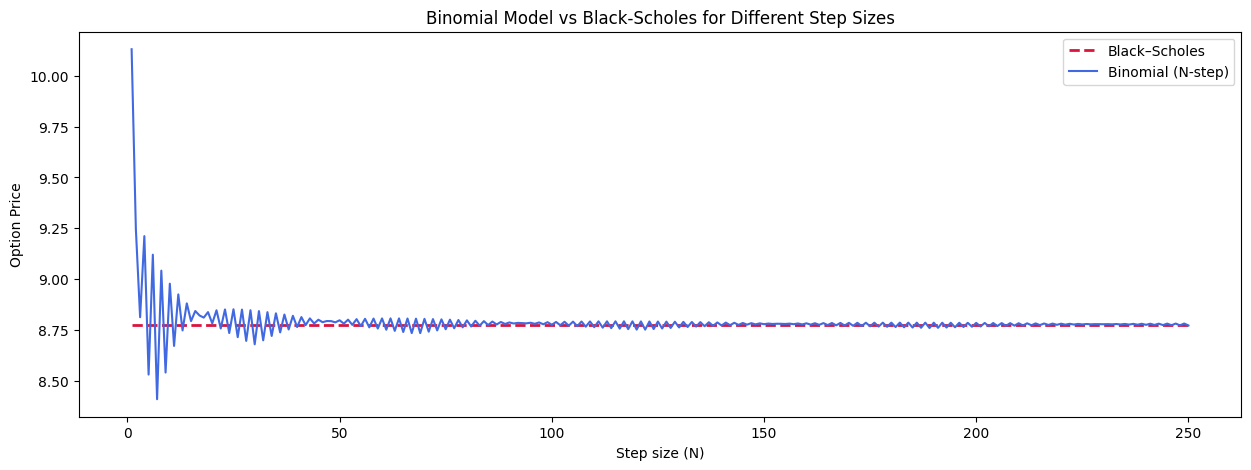

In [ ]:
N = 250
bs_price = black_scholes_call(S0, K, r, T, sigma)
bnm_price = []

for i in range(1, N+1):
    price, _, _ = LatticeEurCall(S0, K, r, T, sigma, i)
    bnm_price.append(price)

plt.figure(figsize=(15,5))
plt.plot(range(1, N+1), [bs_price]*N, color="crimson",linestyle='--',linewidth=2, label="Black–Scholes")
plt.plot(range(1, N+1), bnm_price, color='royalblue', label="Binomial (N-step)")
plt.xlabel("Step size (N)")
plt.ylabel("Option Price")
plt.title("Binomial Model vs Black-Scholes for Different Step Sizes")
plt.legend()